In [1]:
import geopandas as gpd
import pandas as pd


#Read in shapefile tags
landcover = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_landcoverreso7forenv.geojson") #specify which tags to use
biodiversity = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_biodiversityreso7.geojson") #specify which tags to use
sediment = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_sedimentreso7.geojson") #specify which tags to use

DataSourceError: /fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_landcoverreso7forenv.geojson: No such file or directory

In [2]:
protected = gpd.read_file("/fs9/eliviau/hex2vec_project/protectedareas_hokkaido.geojson") #specify which tags to use

In [3]:
landcover.head()

,region_id,landcover_score,geometry
0,872ea9cd4ffffff,0.000000,"POLYGON ((143.36724 44.38845, 143.36326 44.400..."
1,872eadce2ffffff,1.390244,"POLYGON ((144.32251 43.55958, 144.31872 43.572..."
2,872e1bc23ffffff,3.133333,"POLYGON ((141.71423 42.84763, 141.71011 42.859..."
3,872e1aa94ffffff,2.800000,"POLYGON ((142.33694 43.05029, 142.33289 43.062..."
4,872e18d2cffffff,NaN,"POLYGON ((142.77708 41.95575, 142.77316 41.968..."


In [4]:
biodiversity.head()

,region_id,ahp_score,geometry
0,872e1bca5ffffff,9.0,"POLYGON ((141.77841 42.96173, 141.77429 42.973..."
1,872e8db45ffffff,2.0,"POLYGON ((141.92596 45.54248, 141.9217 45.5545..."
2,872eac323ffffff,3.0,"POLYGON ((144.89233 43.67554, 144.88862 43.688..."
3,872e1ea0affffff,6.0,"POLYGON ((143.11584 42.12956, 143.11196 42.142..."
4,872e192ecffffff,4.0,"POLYGON ((140.17834 41.90276, 140.17407 41.914..."


In [5]:
sediment.head()

,region_id,ahp_score,geometry
0,872ea89b6ffffff,10.0,"POLYGON ((144.83066 44.23914, 144.82691 44.251..."
1,872ef0d1bffffff,10.0,"POLYGON ((141.17013 44.63593, 141.16582 44.648..."
2,872e19416ffffff,10.0,"POLYGON ((141.1905 42.24812, 141.18635 42.2603..."
3,872e132dcffffff,10.0,"POLYGON ((144.1739 42.91204, 144.17013 42.9245..."
4,872ef4065ffffff,10.0,"POLYGON ((141.3764 43.83708, 141.37218 43.8492..."


In [6]:
protected.head()

,region_id,index_right,is_protected,geometry
0,872ead465ffffff,NaN,0,"POLYGON ((1227057.47 4882372.75, 1226596.338 4..."
1,872ee6c5bffffff,NaN,0,"POLYGON ((922639.478 4728048.868, 922203.626 4..."
2,872ef438dffffff,NaN,0,"POLYGON ((991411.261 4889606.823, 990968.388 4..."
3,872e132c9ffffff,NaN,0,"POLYGON ((1241965.846 4786885.992, 1241505.514..."
4,872e1b01dffffff,4.0,1,"POLYGON ((1001541.458 4771546.854, 1001099.245..."


In [7]:
biodiversity = biodiversity.rename(columns={"ahp_score": "biodiversity_score"})
sediment = sediment.rename(columns={"ahp_score": "sediment_score"})

In [8]:
from functools import reduce

dfs = [biodiversity, landcover, sediment]

# Only keep useful columns to avoid geometry conflicts
for df in dfs:
    df.drop(columns="geometry", inplace=True)

# Merge all together on region_id
merged = reduce(lambda left, right: pd.merge(left, right, on="region_id", how="outer"), dfs)


In [9]:
merged.head()

,region_id,biodiversity_score,landcover_score,sediment_score
0,872e1bca5ffffff,9.0,1.515152,10.0
1,872e8db45ffffff,2.0,0.000000,10.0
2,872eac323ffffff,3.0,5.133333,10.0
3,872e1ea0affffff,6.0,1.400000,10.0
4,872e192ecffffff,4.0,2.309524,0.0


In [10]:
weights = {
    "landcover_score": 0.50,
    "biodiversity_score": 0.35,
    "sediment_score": 0.15,
}


In [11]:
merged["ahp_total_score"] = sum(
    merged[col] * weight for col, weight in weights.items()
)


In [12]:
merged.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000
2,872eac323ffffff,3.0,5.133333,10.0,5.116667
3,872e1ea0affffff,6.0,1.400000,10.0,4.300000
4,872e192ecffffff,4.0,2.309524,0.0,2.554762


In [13]:
#join geometry back

#reload anyone of the datasets to get one with geometry
biodiversity = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_biodiversityreso7.geojson") #specify which tags to use

#extract geometry from slope and merge it back to the merged dataframe
biodiversity_geometry = biodiversity[["region_id", "geometry"]]
final = merged.merge(biodiversity_geometry, on="region_id", how="left")
final = gpd.GeoDataFrame(final, geometry="geometry", crs=biodiversity.crs)

final.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,"POLYGON ((141.77841 42.96173, 141.77429 42.973..."
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545..."
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,"POLYGON ((144.89233 43.67554, 144.88862 43.688..."
3,872e1ea0affffff,6.0,1.400000,10.0,4.300000,"POLYGON ((143.11584 42.12956, 143.11196 42.142..."
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,"POLYGON ((140.17834 41.90276, 140.17407 41.914..."


ADD TH PROTECTED AREAS RESTRICTIONS!!

In [14]:
# Merge on region_id
final = final.merge(
    protected[["region_id", "is_protected"]],
    on="region_id",
    how="left"
)


In [15]:
final.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0
3,872e1ea0affffff,6.0,1.400000,10.0,4.300000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0


In [16]:
#IF is_protected = 1, THEN ahp_total_score = 0
final.loc[final["is_protected"] == 1, "ahp_total_score"] = 0

In [45]:
#save final to output
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/ahp_technoeco_ntotalscore_hokkaido.geojson", driver="GeoJSON")

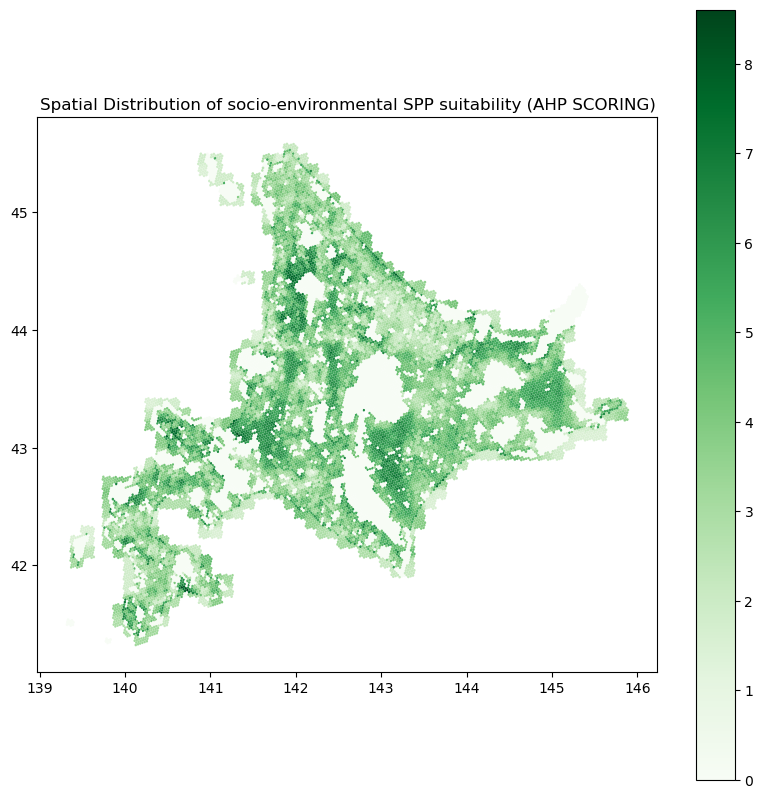

In [43]:
#first vizualise one quick map

from matplotlib import pyplot as plt

final.plot(
    column='ahp_total_score',
    cmap='Greens',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of socio-environmental SPP suitability (AHP SCORING)")
plt.show()


/tmp/ipykernel_111616/767679646.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


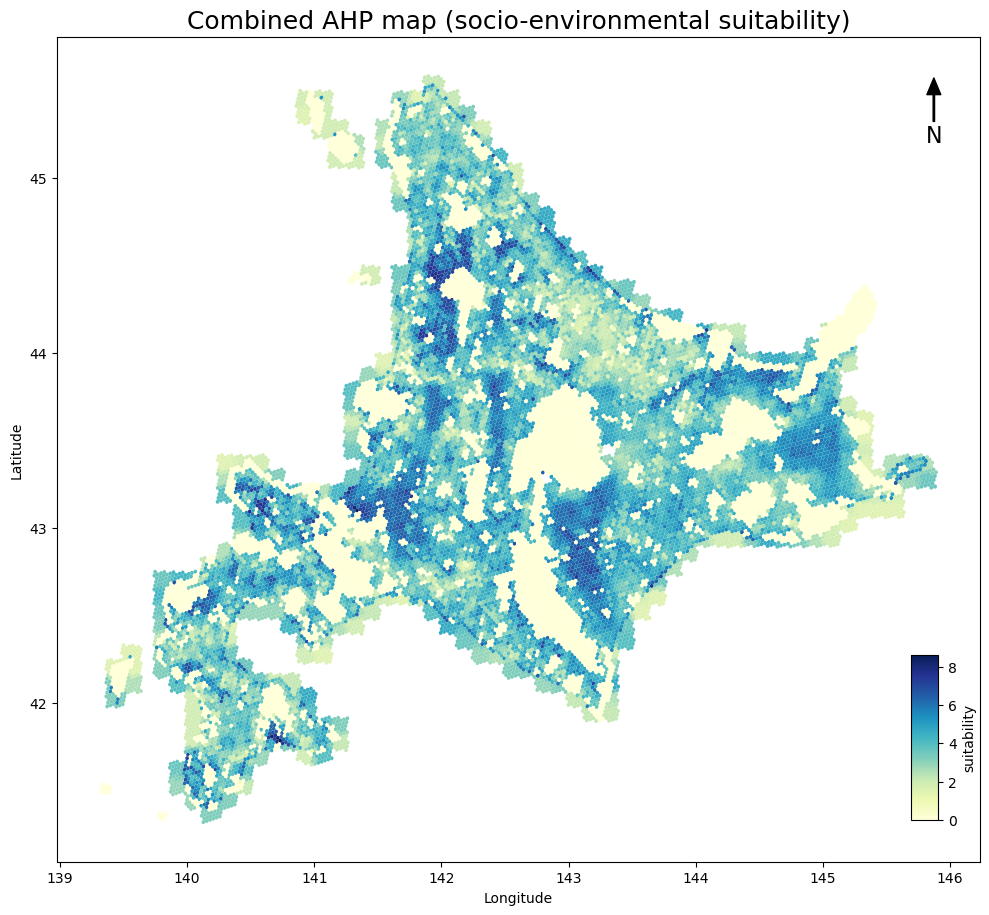

In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = final.plot(
    column='ahp_total_score',
    cmap='YlGnBu',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=final['ahp_total_score'].min(), vmax=final['ahp_total_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("suitability")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Combined AHP map (socio-environmental suitability)", fontsize=18)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


In [46]:
#regions_scored save to output
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/ahp_socioenv_totalscore_hokkaido3.geojson", driver="GeoJSON")

In [24]:
#Now create map with srai plotting tools and save

from srai.plotting import plot_numeric_data

#remettre le index 
final = final.set_index("region_id")

m = plot_numeric_data(final, "ahp_total_score", colormap="YlGnBu", opacity=0.6)
m.save("ahp_totalscore_hokkaido_mapreso7.html")


## ANALYZE GAP WITH GROUND TRUTH

In [17]:
#CLASSIFICATION ENVIRONMENT STARTS HERE

#Read in solar plant location and create prefecture mappings for readability

import geopandas as gpd
import pandas as pd


stations_gdf = ...

#Path for solar PV ground truth data
#Reading in training dataset
data_path = '/home/janelle9/Japan-GIS-Data/camila.csv'
stations_raw = pd.read_csv(data_path)
stations_gdf = gpd.GeoDataFrame(
    stations_raw,
    geometry=gpd.GeoSeries.from_xy(stations_raw["longitude"], stations_raw["latitude"]),
    crs="EPSG:4326",
)

#Reading in our validation dataset
data_path = "/home/janelle9/Japan-GIS-Data/validation.csv"
validation_raw = pd.read_csv(data_path)
validation_gdf = gpd.GeoDataFrame(
    stations_raw,
    geometry=gpd.GeoSeries.from_xy(stations_raw["longitude"], stations_raw["latitude"]),
    crs="EPSG:4326",
)


#Define regions of Japan
regional_prefectures = {
    "Hokkaido": ["Hokkaido"],
    "Tohoku":["Akita", "Aomori", "Fukushima", "Iwate", "Miyagi", "Yamagata"],
    "Chugoku": ["Hiroshima", "Okayama", "Shimane", "Tottori", "Yamaguchi"],
    "Kansai": ["Kyoto", "Shiga", "Osaka", "Nara", "Mie", "Wakayama", "Hyogo"],
    "Chubu": ["Niigata", "Toyama", "Ishikawa", "Fukui", "Yamanashi", "Nagano", "Gifu", "Shizuoka", "Aichi"],
    "Kanto": ["Ibaraki", "Tochigi", "Gunma", "Saitama", "Chiba", "Tokyo", "Kanagawa"],
    "Shikoku": ["Tokushima", "Kagawa", "Ehime", "Kochi"],
    "Kyushu": ["Fukuoka", "Saga", "Nagasaki", "Kumamoto", "Oita", "Miyazaki", "Kagoshima", "Okinawa"]   
}

#mappings are based on Japan ISO coding, these mappings are used in conjunction with our srai.regionalizers
prefecture_mapping = {
    1: "Hokkaido", 2: "Aomori", 3: "Iwate", 4: "Miyagi", 5: "Akita",
    6: "Yamagata", 7: "Fukushima", 8: "Ibaraki", 9: "Tochigi", 10: "Gunma",
    11: "Saitama", 12: "Chiba", 13: "Tokyo", 14: "Kanagawa", 15: "Niigata",
    16: "Toyama", 17: "Ishikawa", 18: "Fukui", 19: "Yamanashi", 20: "Nagano",
    21: "Gifu", 22: "Shizuoka", 23: "Aichi", 24: "Mie", 25: "Shiga",
    26: "Kyoto", 27: "Osaka", 28: "Hyogo", 29: "Nara", 30: "Wakayama",
    31: "Tottori", 32: "Shimane", 33: "Okayama", 34: "Hiroshima",
    35: "Yamaguchi", 36: "Tokushima", 37: "Kagawa", 38: "Ehime", 39: "Kochi",
    40: "Fukuoka", 41: "Saga", 42: "Nagasaki", 43: "Kumamoto",
    44: "Oita", 45: "Miyazaki", 46: "Kagoshima", 47: "Okinawa"
}

#Create a dataframe containing all PV locations, sort by prefecture
stations_gdf['prefecture'] = stations_gdf['prefecture'].map(prefecture_mapping) 

stations_gdf.head()



,ID,prefecture,latitude,longitude,power,geometry
0,3,Wakayama,34.271913,135.135274,1.3020,POINT (135.13527 34.27191)
1,7,Wakayama,34.279023,135.141710,2.7940,POINT (135.14171 34.27902)
2,8,Wakayama,34.182374,135.210084,1.6000,POINT (135.21008 34.18237)
3,9,Wakayama,34.280621,135.098882,21.0000,POINT (135.09888 34.28062)
4,10,Wakayama,34.290981,135.084250,23.9424,POINT (135.08425 34.29098)


In [18]:
#Cell A2
# #run this code to select a single prefecture
from srai.regionalizers import geocode_to_region_gdf

#download region data
select_prefecture = "Hokkaido"
geocode_to_region_string = str(select_prefecture + " Prefecture, Japan")
print(geocode_to_region_string)
prefecture = geocode_to_region_gdf(geocode_to_region_string)

power_plants = stations_gdf[(stations_gdf['prefecture'] == select_prefecture)]



Hokkaido Prefecture, Japan


/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [19]:
power_plants.head()

,ID,prefecture,latitude,longitude,power,geometry
42,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654)
43,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094)
44,106,Hokkaido,43.198158,140.775253,1.98016,POINT (140.77525 43.19816)
45,111,Hokkaido,42.948497,141.814784,1.20400,POINT (141.81478 42.9485)
46,112,Hokkaido,43.050081,141.804632,0.92400,POINT (141.80463 43.05008)


In [20]:
#save power_plants to output

power_plants.to_file(f"/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/power_plants_hokkaido.geojson", driver="GeoJSON")

In [49]:
final.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0


In [50]:
import geopandas as gpd

# 1. Vérifier que les deux jeux ont le même CRS
power_plants = power_plants.to_crs(final.crs)

# 2. Spatial join : associe chaque centrale solaire à l'hexagone dans lequel elle tombe
joined = gpd.sjoin(power_plants, final[["region_id", "geometry"]], how="left", predicate="within")

# 3. Créer une colonne binaire : 1 si au moins une centrale dans l’hexagone, sinon 0
# Récupère les region_id où une centrale est présente
regions_with_plant = joined["region_id"].dropna().unique()

# 4. Ajouter la colonne binaire à ton GeoDataFrame
final["SPP_presence"] = final["region_id"].apply(lambda x: 1 if x in regions_with_plant else 0)

# 5. Vérifie le résultat
final[["region_id", "ahp_total_score", "SPP_presence"]].head()


,region_id,ahp_total_score,SPP_presence
0,872e1bca5ffffff,5.407576,0
1,872e8db45ffffff,2.200000,0
2,872eac323ffffff,5.116667,0
3,872e1ea0affffff,0.000000,0
4,872e192ecffffff,2.554762,1


In [51]:
final.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected,SPP_presence
0,872e1bca5ffffff,9.0,1.515152,10.0,5.407576,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0,0
1,872e8db45ffffff,2.0,0.000000,10.0,2.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0,0
2,872eac323ffffff,3.0,5.133333,10.0,5.116667,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0,0
3,872e1ea0affffff,6.0,1.400000,10.0,0.000000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1,0
4,872e192ecffffff,4.0,2.309524,0.0,2.554762,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0,1


In [52]:
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/SSPpresenceandscoresocioenvhokkaido3.geojson", driver="GeoJSON")

In [17]:
##add powerplants locations of my map 

from srai.plotting import plot_numeric_data

#remettre le index 
final = final.set_index("region_id")  #Can only be run once. If theres an error, restart kernel and run this cell without running the previous map one

m = plot_numeric_data(final, "ahp_total_score", colormap="Greens", opacity=0.6)
power_plants.explore(m=m, color='black')
m.save("ahp_socioenv_totalscore_hokkaido__withspp_map.html")

analyse conflict

In [22]:
# Define low suitability threshold
LOW_SUIT_THRESHOLD = 5  # or use merged['ahp_total_score'].quantile(0.25) for bottom 25%

# Create a binary flag for low suitability
final["suitability_class"] = final["ahp_total_score"].apply(lambda x: "low" if x < LOW_SUIT_THRESHOLD else "high")


In [23]:
final.head()


,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected,SPP_presence,suitability_class
0,872e1bca5ffffff,9.0,1.515152,10.0,6.256061,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0,0,high
1,872e8db45ffffff,2.0,0.000000,10.0,3.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0,0,low
2,872eac323ffffff,3.0,5.133333,10.0,5.603333,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0,0,high
3,872e1ea0affffff,6.0,1.400000,10.0,5.160000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1,0,high
4,872e192ecffffff,4.0,2.309524,0.0,2.323810,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0,1,low


In [24]:
import geopandas as gpd

# 1. Vérifier que les deux jeux ont le même CRS
power_plants = power_plants.to_crs(final.crs)

# 2. Spatial join : associe chaque centrale solaire à l'hexagone dans lequel elle tombe
joined = gpd.sjoin(power_plants, final[["region_id", "geometry"]], how="left", predicate="within")

# 3. Créer une colonne binaire : 1 si au moins une centrale dans l’hexagone, sinon 0
# Récupère les region_id où une centrale est présente
regions_with_plant = joined["region_id"].dropna().unique()

# 4. Ajouter la colonne binaire à ton GeoDataFrame
final["SPP_presence"] = final["region_id"].apply(lambda x: 1 if x in regions_with_plant else 0)

# 5. Vérifie le résultat
final[["region_id", "ahp_total_score", "SPP_presence"]].head()


,region_id,ahp_total_score,SPP_presence
0,872e1bca5ffffff,6.256061,0
1,872e8db45ffffff,3.200000,0
2,872eac323ffffff,5.603333,0
3,872e1ea0affffff,5.160000,0
4,872e192ecffffff,2.323810,1


In [25]:
final.head()

,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected,SPP_presence,suitability_class
0,872e1bca5ffffff,9.0,1.515152,10.0,6.256061,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0,0,high
1,872e8db45ffffff,2.0,0.000000,10.0,3.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0,0,low
2,872eac323ffffff,3.0,5.133333,10.0,5.603333,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0,0,high
3,872e1ea0affffff,6.0,1.400000,10.0,5.160000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1,0,high
4,872e192ecffffff,4.0,2.309524,0.0,2.323810,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0,1,low


In [20]:
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/SSPpresenceandscoresocioenvhokkaido.geojson", driver="GeoJSON")

In [17]:
# Ensure both GeoDataFrames are in the same CRS
power_plants = power_plants.to_crs(final.crs)

# Spatial join: attach suitability score to each power plant
conflict_zones = gpd.sjoin(power_plants, final[["geometry", "ahp_total_score", "suitability_class"]], how="inner", predicate="within")

# Filter: Only those in LOW suitability
conflicts = conflict_zones[conflict_zones["suitability_class"] == "low"]


In [21]:
conflicts.head(300)

,ID,prefecture,latitude,longitude,power,geometry,index_right,ahp_total_score,suitability_class
42,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654),6093,2.384082,low
43,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094),4,2.176429,low
44,106,Hokkaido,43.198158,140.775253,1.98016,POINT (140.77525 43.19816),27119,4.029474,low
46,112,Hokkaido,43.050081,141.804632,0.92400,POINT (141.80463 43.05008),12795,3.898125,low
47,116,Hokkaido,42.697339,141.886706,1.51290,POINT (141.88671 42.69734),9700,1.395625,low
...,...,...,...,...,...,...,...,...,...
12693,18346,Hokkaido,42.970202,141.502486,1.20910,POINT (141.50249 42.9702),21707,2.640000,low
13259,19129,Hokkaido,43.194344,140.899364,2.30230,POINT (140.89936 43.19434),26833,2.369231,low
13379,19353,Hokkaido,42.971391,140.515692,1.95510,POINT (140.51569 42.97139),358,2.834118,low
13380,19354,Hokkaido,42.971681,140.519059,3.17610,POINT (140.51906 42.97168),358,2.834118,low


In [1]:
final.head()

NameError: name 'final' is not defined

In [ ]:
#regions_scored save to output
conflicts.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/conflicts_socioenv_totalscore_hokkaido.geojson", driver="GeoJSON")

In [27]:
conflicts.to_file("conflict_zones.geojson", driver="GeoJSON")


In [23]:
#remettre le index 
conflicts = conflicts.set_index("region_id")  #Can only be run once. If theres an error, restart kernel and run this cell without running the previous map one


KeyError: "None of ['region_id'] are in the columns"

In [27]:

#remettre le index 
final = final.set_index("region_id")  #Can only be run once. If theres an error, restart kernel and run this cell without running the previous map one

In [28]:
from srai.plotting import plot_numeric_data

# (1) Plot the AHP suitability map
m = plot_numeric_data(final, "ahp_total_score", colormap="Greens", opacity=0.6)

# (2) Define conflict threshold
LOW_SUIT_THRESHOLD = 5  # or use a percentile

# (3) Create a mask for low-score zones
low_suit_zones = final[final["ahp_total_score"] < LOW_SUIT_THRESHOLD]

# (4) Spatial join: Power plants located in low-suitability zones
conflicts = gpd.sjoin(power_plants.to_crs(final.crs), low_suit_zones, how="inner", predicate="within")

# (5) Add ALL power plants in black
power_plants.explore(m=m, color='black', marker_kwds={'radius': 4, 'fill': True})

# (6) Add CONFLICTED power plants in red
conflicts.explore(m=m, color='red', marker_kwds={'radius': 6, 'fill': True, 'fillColor': 'red'})

# (7) Save map
m.save("ahp_totalscore_hokkaido_with_conflict_zones_socioenvFINAL.html")

In [29]:
final.head()

,biodiversity_score,landcover_score,sediment_score,ahp_total_score,geometry,is_protected,SPP_presence,suitability_class
region_id,,,,,,,,
872e1bca5ffffff,9.0,1.515152,10.0,6.256061,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",0,0,high
872e8db45ffffff,2.0,0.000000,10.0,3.200000,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",0,0,low
872eac323ffffff,3.0,5.133333,10.0,5.603333,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",0,0,high
872e1ea0affffff,6.0,1.400000,10.0,5.160000,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",1,0,high
872e192ecffffff,4.0,2.309524,0.0,2.323810,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",0,1,low


In [22]:
conflicts.head()

,ID,prefecture,latitude,longitude,power,geometry,region_id,biodiversity_score,landcover_score,sediment_score,ahp_total_score,suitability_class
42,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654),872e192e8ffffff,4.0,3.224490,0.0,2.384082,low
43,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094),872e192ecffffff,4.0,2.595238,0.0,2.176429,low
44,106,Hokkaido,43.198158,140.775253,1.98016,POINT (140.77525 43.19816),872e1b644ffffff,8.0,4.210526,0.0,4.029474,low
46,112,Hokkaido,43.050081,141.804632,0.92400,POINT (141.80463 43.05008),872e1bcb3ffffff,9.0,2.812500,0.0,3.898125,low
47,116,Hokkaido,42.697339,141.886706,1.51290,POINT (141.88671 42.69734),872e1868affffff,3.0,1.229167,0.0,1.395625,low


In [25]:
conflicts.shape

(11, 14)

In [28]:
#read file
techno_env_conflict= gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/conflicts_technoecon_hokkaido.geojson")

In [32]:
socio_env_conflict = conflicts

In [45]:
techno_env_conflict.head()

,ID,prefecture,latitude,longitude,power,region_id,slope_score,aspect_score,ahp_solar_score,technoecon_score,suitability_class,geometry
0,85,Hokkaido,41.926540,140.149396,1.10592,872e192e8ffffff,8.750000,0.454545,5.0,4.761364,low,POINT (140.1494 41.92654)
1,89,Hokkaido,41.909399,140.153836,2.35530,872e192ecffffff,9.272727,0.000000,5.0,4.781818,low,POINT (140.15384 41.9094)
2,513,Hokkaido,43.259562,140.632365,1.19808,872ef59a5ffffff,8.272727,0.312500,6.0,4.975568,low,POINT (140.63236 43.25956)
3,10046,Hokkaido,45.396993,141.750065,5.01000,872ef6632ffffff,9.090909,1.909091,3.0,4.500000,low,POINT (141.75006 45.39699)
4,13560,Hokkaido,42.225395,140.340437,1.42560,872ee69a6ffffff,6.800000,0.000000,7.0,4.840000,low,POINT (140.34044 42.2254)


In [44]:
techno_env_conflict = techno_env_conflict.rename(columns={"ahp_total_score": "technoecon_score"})

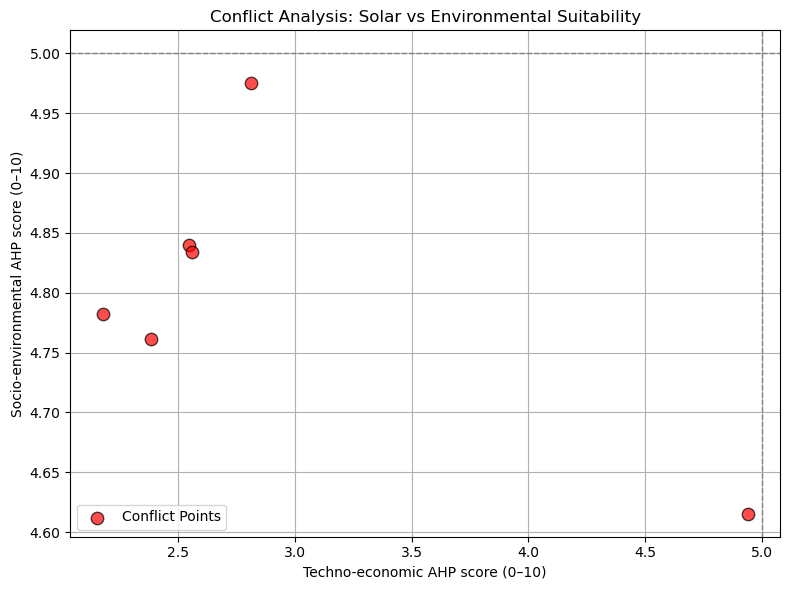

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge the two datasets on a shared ID or region_id
merged = pd.merge(socio_env_conflict, techno_env_conflict, on="ID")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    merged["ahp_total_score"], 
    merged["technoecon_score"], 
    c="red", 
    edgecolors="black", 
    s=80,
    alpha=0.7,
    label="Conflict Points"
)

# Add threshold lines
plt.axhline(y=5, color="gray", linestyle="--", linewidth=1)
plt.axvline(x=5, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Techno-economic AHP score (0–10)")
plt.ylabel("Socio-environmental AHP score (0–10)")
plt.title("Conflict Analysis: Solar vs Environmental Suitability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
